<a href="https://colab.research.google.com/github/jooyoung227/ESAA-14-23-/blob/main/YB_0403_session2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 모듈 및 데이터 로드
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

data = load_breast_cancer()

# x, y 데이터 생성
X = data.data

# 악성을 1, 양성을 0으로
y = 1 - data.target

# 특징으로 사용할 데이터를 평균으로 구분하는 10개 열로 축소
X = X[:, :10]

# 로지스틱 회귀 모델 생성
model_lor = LogisticRegression(solver = 'lbfgs')
model_lor.fit(X,y)
y_pred = model_lor.predict(X)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**오차 행렬(혼동 행렬) 생성**

In [2]:
# 종속 변수와 예측 결과로 혼동 행렬 생성
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, y_pred)
cm

array([[337,  20],
       [ 30, 182]])

**정확도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [3]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y, y_pred)
acc

0.9121265377855887

정확도는 전체 데이터 중에서 모데이 맞게 예측한 비율이다   
(TP + TN) / (TP + TN + FP + FN)  
여기서 정확도는 약 0.912로 이는 전체 데이터 중 약91.2%를 모델이 올바르게 분류했다는 뜻이다.

**정밀도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [5]:
from sklearn.metrics import precision_score

precision = precision_score(y, y_pred)
precision

0.900990099009901

정밀도는 모데이 악성이라고 예측한 것들 중 실제로 악성인 비율이다.   
TP / (TP + FP)  
정밀도는 약 0.901, 즉 90.1%이다.  
이는 모델이 악성이라고 판단한 환자 중 약 90.1%가 실제로 악성이라는 뜻이다.
따라서 이 모델은 악성이라고 예측한 결과의 신뢰도가 비교적 높은 편이라고 볼 수 있다.

**재현율의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [6]:
from sklearn.metrics import recall_score

recall = recall_score(y, y_pred)
recall

0.8584905660377359

재현율은 실제 악성인 데이터 중에서 모델이 악성으로 올바르게 찾아낸 비율이다.  
TP / (TP + FN)  
재현율은 약 0.858, 즉 85.8%이다.  
이는 실제 악성 환자 중 약 85.8%를 모델이 악성으로 찾아냈고 약 14.2%의 악성 환자는 놓쳤다는 의미이다.

**F1 score의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [7]:
from sklearn.metrics import f1_score

f1 = f1_score(y, y_pred)
f1

0.8792270531400966

F1 score는 정밀도와 재현율의 조화평균으로, 두 값을 균형 있게 반영하는 지표이다.  
2 * (precision * recall) / (precision + recall)  
F1 score는 약 0.879이다.  
이는 정밀도와 재현율을 함께 고려했을 때 모델의 성능이 전반적으로 우수하다는 것을 의미한다.

**예측 확률(pred_proba) : 0으로 예측할 확률이 0.1보다 크면 y_pred2 에 넣는다 가정.**

In [8]:
from sklearn.preprocessing import Binarizer


In [10]:
# y과 y_pred2의 혼동행렬, 정확도, 정밀도, 재현율, f1 score 구하기
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# 0으로 예측할 확률
proba_0 = model_lor.predict_proba(X)[:, 0]

# 0일 확률이 0.1보다 크면 0, 아니면 1
y_pred2 = np.where(proba_0 > 0.1, 0, 1)

cm2 = confusion_matrix(y, y_pred2)
acc2 = accuracy_score(y, y_pred2)
precision2 = precision_score(y, y_pred2)
recall2 = recall_score(y, y_pred2)
f12 = f1_score(y, y_pred2)

print("혼동행렬:\n", cm2)
print("정확도:", acc2)
print("정밀도:", precision2)
print("재현율:", recall2)
print("F1 score:", f12)

혼동행렬:
 [[356   1]
 [ 73 139]]
정확도: 0.8699472759226714
정밀도: 0.9928571428571429
재현율: 0.6556603773584906
F1 score: 0.7897727272727273


**ROC 곡선 시각화**

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score


In [15]:
import matplotlib.pyplot as plt


**ROC AUC 값을 구하고 해당 값을 통해 알 수 있는 점을 쓰시오.**

ROC AUC: 0.974076423022039


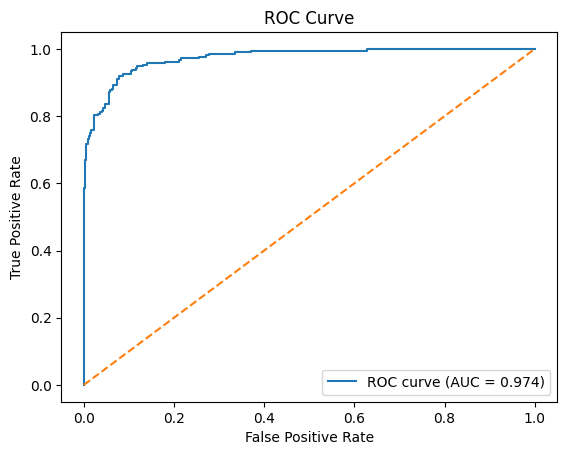

In [16]:
# 악성(1)일 확률
pred_proba_1 = model_lor.predict_proba(X)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y, pred_proba_1)

# ROC AUC
roc_auc = roc_auc_score(y, pred_proba_1)
print("ROC AUC:", roc_auc)

# 그래프
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

ROC AUC 값은 약 0.974이다.
이는 모델이 양성과 악성을 매우 잘 구분하고 있다는 뜻이다.
즉, 임의의 악성 샘플과 양성 샘플을 하나씩 뽑았을 때, 모델이 악성 샘플에 더 높은 위험 점수를 줄 확률이 약 97.4%라고 해석할 수 있다.
따라서 이 모델의 판별력은 매우 우수한 편이라고 볼 수 있다.